# Generation, MDN NLL oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic import MIMIC, GenerationPolicy, ResNetEncoder, NeuralConditionalSampler, IdentityDecoder, IdentityEncoder
from mimic_notebook_utils import (
    append_generated_rows,
    cell_sampling_trace,
    class_balance,
    generated_embedding_trace,
    identity_generation_plot,
    make_two_spiral_frame,
    plot_oversampling,
)

MAJORITY_SAMPLES = 250
MINORITY_SAMPLES = MAJORITY_SAMPLES // 2

df = make_two_spiral_frame(
    majority_samples=MAJORITY_SAMPLES,
    minority_samples=MINORITY_SAMPLES,
    random_state=2,
)

display(class_balance(df).style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,250
minority,125


,x,y,label,id
0,0.247798,0.090811,majority,0
1,0.168761,0.206043,majority,1
2,0.186642,0.008847,majority,2
3,-0.053813,0.116717,majority,3
4,0.456219,0.104372,majority,4
5,0.376696,0.070445,majority,5
6,0.197465,0.467894,majority,6
7,0.324404,0.371906,majority,7


In [2]:
mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=ResNetEncoder(embedding_dim=8, hidden_dim=8, n_layers=2, dropout=0.05, max_epochs=30, patience=5, batch_size=64, random_state=2),
    decoder=NeuralConditionalSampler(
        n_components=5,
        hidden_dim=32,
        n_layers=2,
        dropout=0.05,
        max_epochs=80,
        patience=8,
        batch_size=64,
        component_temperature=1.0,
        noise_scale=1.0,
        random_state=2,
    ),
    policy=GenerationPolicy(method="displacement", neighbour_mode="mutual", n_neighbors=5, lambda_range=(0.25, 0.75)),
    n_bootstrap=1,
    random_state=2,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(generated_embedding_trace(synthetic, trace).head(8).style.set_caption("MDN NLL generated rows with embedding trace"))
display(cell_sampling_trace(trace).head(12).style.set_caption("Per-cell MDN NLL sampling trace"))


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,decoder
0,1.146637,-1.915980,minority,314.000000,315.000000,314.000000,0.399246,mutual,NeuralConditionalSampler
1,-0.526842,-1.786940,minority,305.000000,303.000000,304.000000,0.550050,mutual,NeuralConditionalSampler
2,-1.296628,-1.842700,minority,304.000000,306.000000,304.000000,0.343951,mutual,NeuralConditionalSampler
3,0.036093,0.645467,majority,20.000000,6.000000,16.000000,0.578717,mutual,NeuralConditionalSampler
4,1.332381,1.526726,majority,114.000000,112.000000,114.000000,0.325031,mutual,NeuralConditionalSampler
5,-2.339944,-1.154795,majority,162.000000,163.000000,162.000000,0.461392,mutual,NeuralConditionalSampler
6,0.545378,-1.516348,majority,82.000000,85.000000,82.000000,0.733718,mutual,NeuralConditionalSampler
7,-0.519646,-0.257362,minority,256.000000,258.000000,259.000000,0.343626,mutual,NeuralConditionalSampler


,trace_type,sample_index,method,decoder,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability,sampled_class_code,class_probabilities
12,cell,0,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,1.130719,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.420794,0.662378,0.075371,1.450122,nan,nan
13,cell,1,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,-0.461124,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.254850,-0.404840,0.137515,0.663694,nan,nan
14,cell,2,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,-0.998251,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.261608,-0.676013,0.143147,0.755463,nan,nan
15,cell,3,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,0.182260,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.226890,0.023861,0.075716,1.015809,nan,nan
16,cell,4,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,1.139832,z_minus_j,0.000000,8.000000,0.000000,2.000000,0.493869,0.720330,0.101108,1.046702,nan,nan
17,cell,5,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,-1.834210,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.246097,-1.372321,0.124120,-0.865558,nan,nan
18,cell,6,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,0.495486,z_minus_j,0.000000,8.000000,0.000000,2.000000,0.375507,0.402453,0.111652,0.987632,nan,nan
19,cell,7,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,-0.024737,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.244935,-0.132807,0.098325,0.930011,nan,nan
20,cell,8,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,0.501929,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.187931,0.172273,0.085821,0.473831,nan,nan
21,cell,9,gibbs_forest,NeuralConditionalSampler,0.000000,x,regression,1.361669,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.399925,0.709345,0.092656,0.468070,nan,nan


In [3]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
minority_synthetic, minority_trace = mimic.sample(
    minority_needed,
    condition={"label": "minority"},
    return_trace=True,
)
balanced = append_generated_rows(df, minority_synthetic)

display(class_balance(balanced).style.set_caption("Class balance after minority-conditioned displacement oversampling"))
display(generated_embedding_trace(minority_synthetic, minority_trace, include_condition=True).head(8).style.set_caption("Synthetic minority rows with embedding trace"))
display(cell_sampling_trace(minority_trace).head(12).style.set_caption("Minority per-cell stochastic sampling trace"))


,count
label,
majority,250
minority,250


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,-2.699369,-1.965197,minority,354.000000,352.000000,354.000000,0.399246,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
1,-3.190700,-1.090428,minority,351.000000,354.000000,353.000000,0.550050,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
2,-3.001473,-0.807449,minority,351.000000,353.000000,351.000000,0.343951,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
3,0.283237,0.088881,minority,256.000000,260.000000,256.000000,0.578717,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
4,-0.752180,1.197626,minority,288.000000,291.000000,288.000000,0.325031,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
5,-1.438722,-1.578134,minority,304.000000,306.000000,305.000000,0.461392,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
6,0.878251,-0.183419,minority,277.000000,278.000000,276.000000,0.733718,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
7,0.833892,2.842733,minority,335.000000,337.000000,336.000000,0.343626,mutual,"{""label"": ""minority""}",NeuralConditionalSampler


,trace_type,sample_index,method,condition,decoder,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability
125,cell,0,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-3.159057,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.747178,-1.823414,0.139474,0.338787
126,cell,1,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-2.867833,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.214784,-1.831004,0.116923,0.561968
127,cell,2,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-3.009845,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.763097,-1.931976,0.150585,0.917141
128,cell,3,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-0.204153,z_minus_j,0.000000,8.000000,0.000000,2.000000,0.209795,-0.102066,0.110863,1.265002
129,cell,4,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-0.980229,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.597450,-0.502703,0.094710,0.473454
130,cell,5,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-1.047926,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.615729,-0.744734,0.171002,0.798196
131,cell,6,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,0.964376,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.121388,0.641496,0.042123,1.323472
132,cell,7,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,1.061412,z_minus_j,0.000000,8.000000,0.000000,2.000000,0.418088,0.591284,0.093030,1.438294
133,cell,8,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-1.653297,z_minus_j,0.000000,8.000000,0.000000,1.000000,0.237604,-1.059566,0.107318,1.173372
134,cell,9,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,0.000000,x,regression,-1.065997,z_minus_j,0.000000,8.000000,0.000000,0.000000,0.599060,-0.807685,0.108904,0.584732


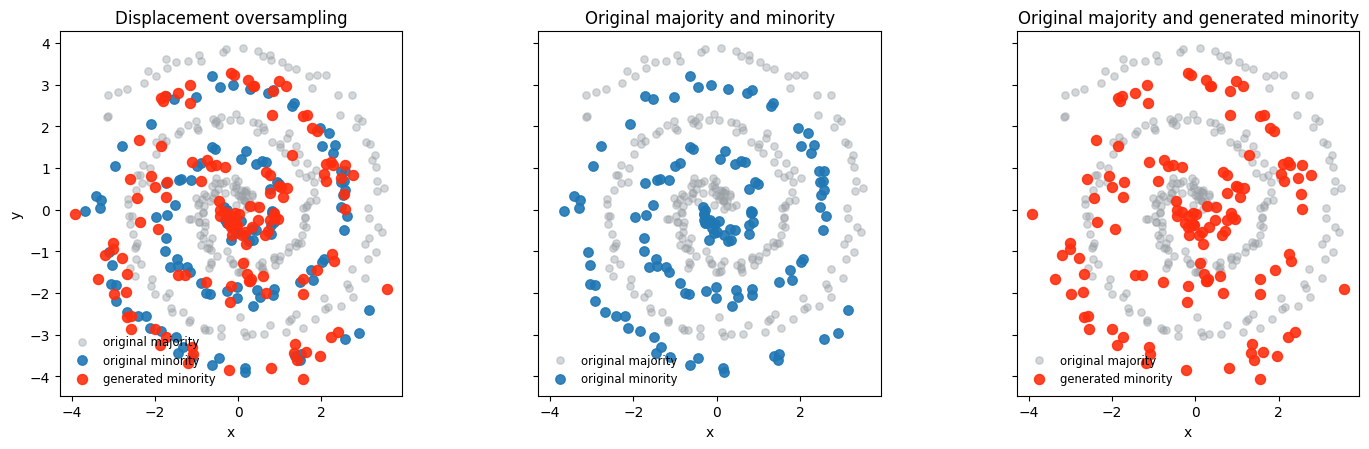

In [4]:
fig, ax = plot_oversampling(df, minority_synthetic)


## Identity-space configurable baseline

Set the full MIMIC estimator here, using `IdentityEncoder` and `IdentityDecoder` to generate in the preprocessed original feature space. Change `identity_policy` to switch between SMOTE-style interpolation and displacement.

,method,neighbour_mode,n_neighbors,lambda_range,n_generated,trace_rows,x_min,x_max,y_min,y_max
0,displacement,mutual,5,"(0.25, 0.75)",125,125,-3.926848,3.325296,-3.653332,3.293510


,x,y,label
0,-3.123998,-1.565269,minority
1,-3.323247,-0.937588,minority
2,-3.175652,-1.313234,minority
3,-0.222088,-0.126378,minority
4,-0.954885,1.235836,minority
5,-1.089171,-1.940325,minority
6,0.991061,0.323475,minority
7,0.662221,3.098248,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,random_state
0,embedding,0,displacement,354,355,353,0.399246,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
1,embedding,1,displacement,351,354,353,0.550050,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
2,embedding,2,displacement,351,350,351,0.343951,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
3,embedding,3,displacement,256,257,258,0.578717,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
4,embedding,4,displacement,288,291,288,0.325031,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
5,embedding,5,displacement,304,306,304,0.461392,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
6,embedding,6,displacement,277,278,274,0.733718,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2
7,embedding,7,displacement,335,334,335,0.343626,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,2


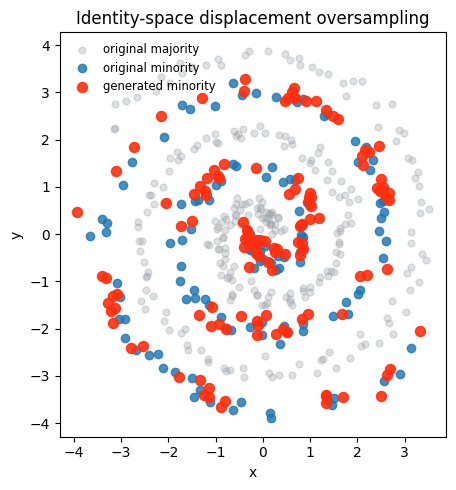

In [5]:
identity_policy = GenerationPolicy(
    method="displacement",  # change to "displacement" for the displacement variant
    neighbour_mode="mutual",
    n_neighbors=5,
    lambda_range=(0.25, 0.75),
)

identity_mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=IdentityEncoder(),
    decoder=IdentityDecoder(),
    policy=identity_policy,
    n_bootstrap=1,
    random_state=2,
)

identity_summary, identity_synthetic, identity_trace, identity_fig, identity_ax = identity_generation_plot(
    identity_mimic,
    df,
    n_samples=minority_needed,
    condition={"label": "minority"},
    title=f"Identity-space {identity_policy.method} oversampling",
)

display(identity_summary.style.set_caption("Identity-space generation summary"))
display(identity_synthetic.head(8).style.set_caption("Identity-space synthetic minority rows"))
display(identity_trace.head(8).style.set_caption("Identity-space generation trace"))